In [4]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Carga desde un archivo .csv sin indice
data=pd.read_csv('Citas_Digital_Limpieza_Nulos.csv') 
data

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,Sin dato,Guillermo,Sin dato,Finalizado,0.90,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,Sin dato,Roberto,Sin dato,Finalizado,0.40,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin respuesta
2,Saul,Sin dato,Irving,Sin dato,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,Sin dato,Oswaldo,Sin dato,Venta,0.90,0.0,0.0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",Sin respuesta
4,Saul,Sin dato,Rodrigo,Sin dato,Finalizado,0.90,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,Sin dato,Activo,0.80,1.0,1.0,0.0,Pedro Antonio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
672,Ignacio,2026-07-22,Zaira Macip,Sin dato,Activo,0.50,0.0,0.0,0.0,Aurelio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
673,Ignacio,2026-07-27,Julio Hernandez,Sin dato,Activo,0.50,1.0,0.0,0.0,Victor,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
674,Ignacio,2026-07-24,Xhunaxhi Vicente,Sin dato,Activo,1.00,1.0,1.0,1.0,Ignacio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta


In [13]:
#Verificar info del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       676 non-null    str    
 1   Fecha                                     676 non-null    str    
 2   Nombre Cliente                            676 non-null    str    
 3   Telefono                                  676 non-null    str    
 4   Estatus de Lead                           676 non-null    str    
 5   Potencial de compra                       676 non-null    float64
 6   PDM                                       676 non-null    float64
 7   SDC                                       676 non-null    float64
 8   Venta                                     676 non-null    float64
 9   Asesor Asignado                           676 non-null    str    
 10  ¿Por que no ha visitado la agencia?       676 non

In [8]:
data.describe()

,Potencial de compra,PDM,SDC,Venta
count,676.000000,676.000000,676.000000,676.000000
mean,1.098447,0.501479,0.397929,0.085799
std,5.280653,0.597524,0.489833,0.280274
min,0.000000,0.000000,0.000000,0.000000
25%,0.700000,0.000000,0.000000,0.000000
50%,0.800000,0.000000,0.000000,0.000000
75%,0.800000,1.000000,1.000000,0.000000
max,80.000000,9.000000,1.000000,1.000000


In [14]:
#Creo 2 dataframe para poder procesar los outliers
cuantitativas = data.iloc[:,5:9]
cualitativas = data.iloc[:,[0,1,2,3,4,9,10,11,12,13,14,15]]

<Figure size 1500x800 with 0 Axes>

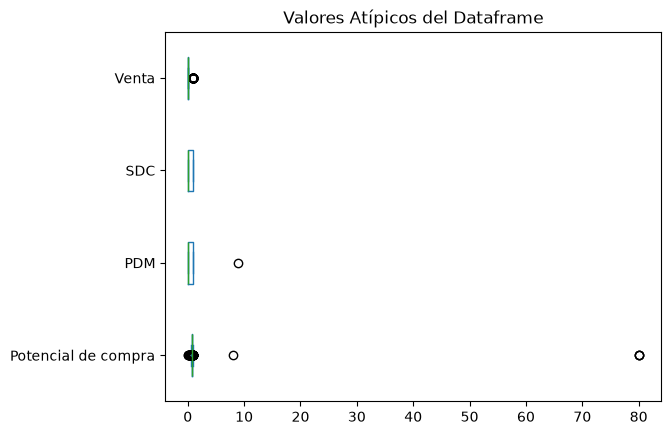

In [15]:
#Realizar diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize=(15,8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [16]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas

Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()

print("Limite Superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite Superior permitido Potencial de compra    16.940406
PDM                     2.294051
SDC                     1.867428
Venta                   0.926621
dtype: float64
Limite inferior permitido Potencial de compra   -14.743513
PDM                    -1.291092
SDC                    -1.071570
Venta                  -0.755024
dtype: float64


In [17]:
#Obtener datos y los outliers se convierten en nulos en el DataFrame
data3 = cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,0.50,0.0,0.0,0.0
673,0.50,1.0,0.0,0.0
674,1.00,1.0,1.0,NaN


In [18]:
#Corroboramos valores nulos del dataframe
valores_nulos = data3.isnull().sum()
valores_nulos

Potencial de compra     3
PDM                     1
SDC                     0
Venta                  58
dtype: int64

In [19]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean = data3.copy()
data_clean = data_clean.fillna(round(data3.mean(),1))
data_clean

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,0.50,0.0,0.0,0.0
673,0.50,1.0,0.0,0.0
674,1.00,1.0,1.0,0.0


In [20]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos = data_clean.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

In [21]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr=percentile75-percentile25

Limite_Superior_iqr=percentile75+1.5*iqr
Limite_Inferior_iqr=percentile25-1.5*iqr

print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
SDC                    2.50
Venta                  0.00
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
SDC                   -1.50
Venta                  0.00
dtype: float64


In [22]:
#Obtenemos datos limpios del Dataframe
data3_iqr = cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,NaN,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,NaN,0.0,0.0,0.0
673,NaN,1.0,0.0,0.0
674,NaN,1.0,1.0,NaN


In [23]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

Potencial de compra    76
PDM                     1
SDC                     0
Venta                  58
dtype: int64

In [24]:
#Reemplazamos valores atípicos (nulos) del dataframe con "median"
#Realizamos una copia del dataframe
data4_iqr = data3_iqr.copy()
data4_iqr = data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.80,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,0.80,0.0,0.0,0.0
673,0.80,1.0,0.0,0.0
674,0.80,1.0,1.0,0.0


In [25]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos = data4_iqr.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

In [26]:
#Unir el dataframe cuantitativo limpio con el dataframe cualitativo
Datos_limpios = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limpios

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15,Potencial de compra,PDM,SDC,Venta
0,Saul,Sin dato,Guillermo,Sin dato,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...,0.90,1.0,0.0,0.0
1,Saul,Sin dato,Roberto,Sin dato,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin respuesta,0.80,0.0,0.0,0.0
2,Saul,Sin dato,Irving,Sin dato,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025,0.85,0.0,0.0,0.0
3,Saul,Sin dato,Oswaldo,Sin dato,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",Sin respuesta,0.90,0.0,0.0,0.0
4,Saul,Sin dato,Rodrigo,Sin dato,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,Sin dato,Activo,Pedro Antonio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,0.80,1.0,1.0,0.0
672,Ignacio,2026-07-22,Zaira Macip,Sin dato,Activo,Aurelio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,0.80,0.0,0.0,0.0
673,Ignacio,2026-07-27,Julio Hernandez,Sin dato,Activo,Victor,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,0.80,1.0,0.0,0.0
674,Ignacio,2026-07-24,Xhunaxhi Vicente,Sin dato,Activo,Ignacio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,0.80,1.0,1.0,0.0


In [27]:
#Corroborar valores nulos del dataframe LIMPIO
valores_nulos = Datos_limpios.isnull().sum()
valores_nulos

BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Unnamed: 15                                 0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
dtype: int64

In [28]:
#Convertir DataFrame limpio a CSV
Datos_limpios.to_csv("Citas_Digital_Limpieza_Outliers_IQR.csv", index=False)